# Isolation Kernels: Sinusoids

Which input features help distinguish changes in an oscillating signal? We will:

1. **Visualize oscillations:** generate nominal signals and controlled changes.
2. **Choose input features:** compare positions, transitions, windows, and sequence phase.
3. **Fit isolation regions:** scale training features and fit a kernel for each representation.
4. **Embed and compare:** average features into sequence embeddings; test direction, sampling density, and signal changes.
5. **Compare recent windows:** measure when each representation notices a change.

**Rolling similarity**, called familiarity in the original example, averages similarities to the nearest nominal windows. It is not a probability.

Use the project's `nb` environment. Run all cells; the Summary figures refresh from the results below.


## Summary


### 1. Visualize oscillations

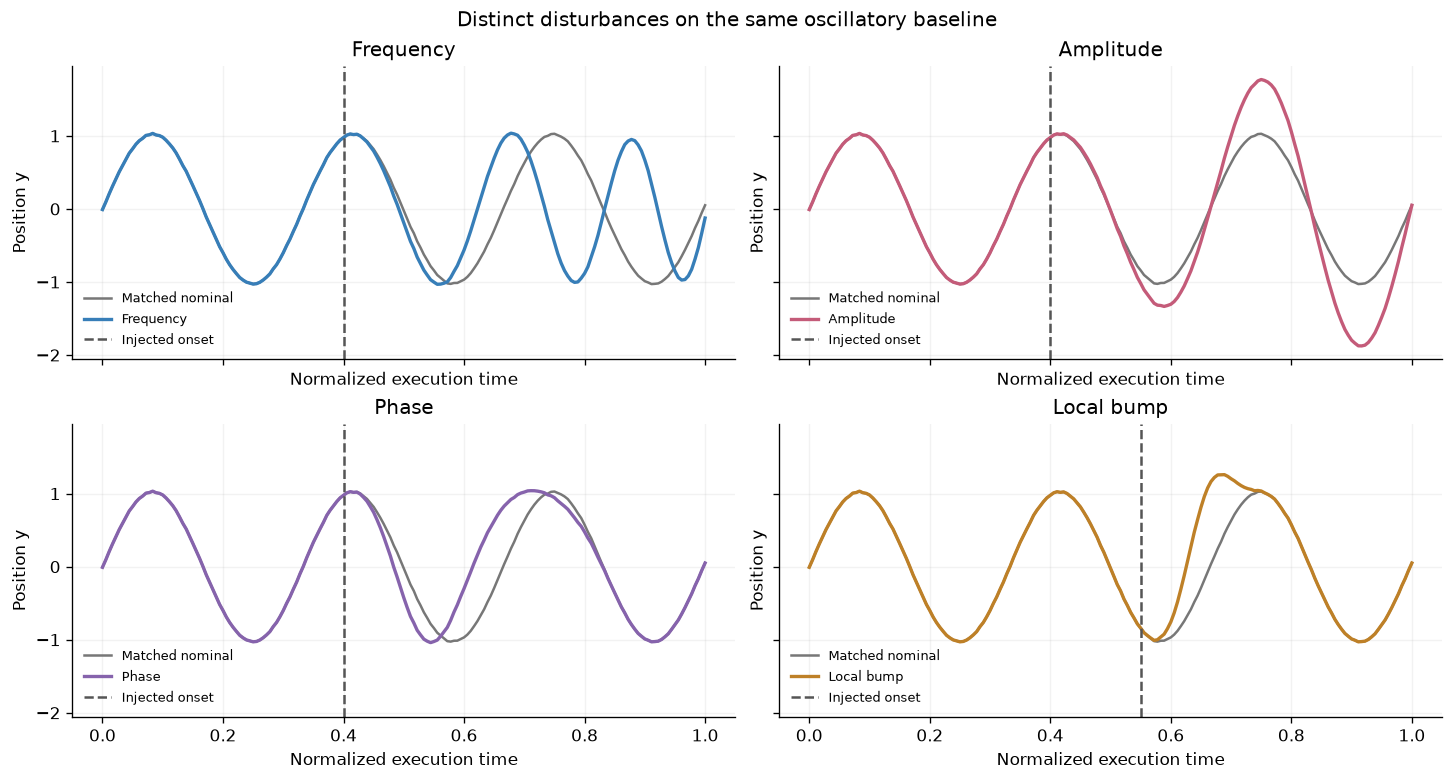

### 2. Choose input features

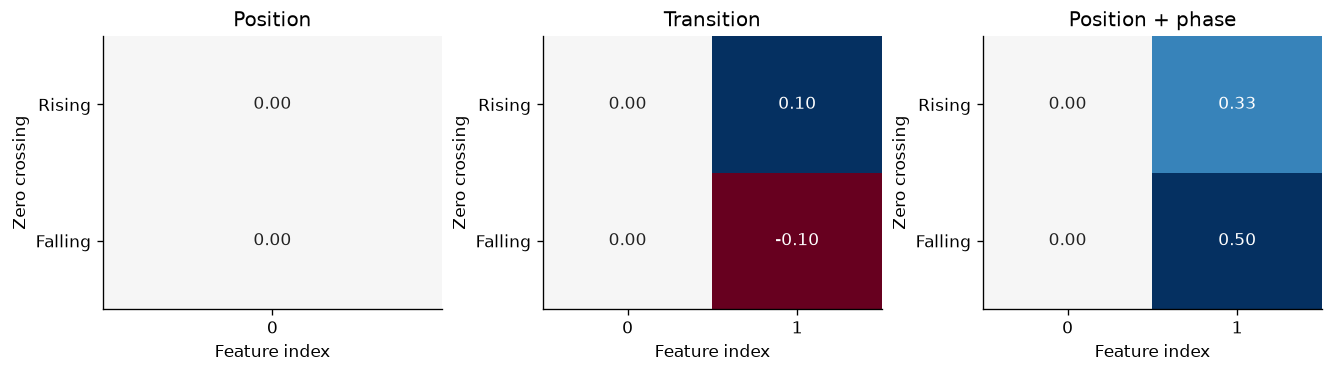

### 3. Fit isolation regions

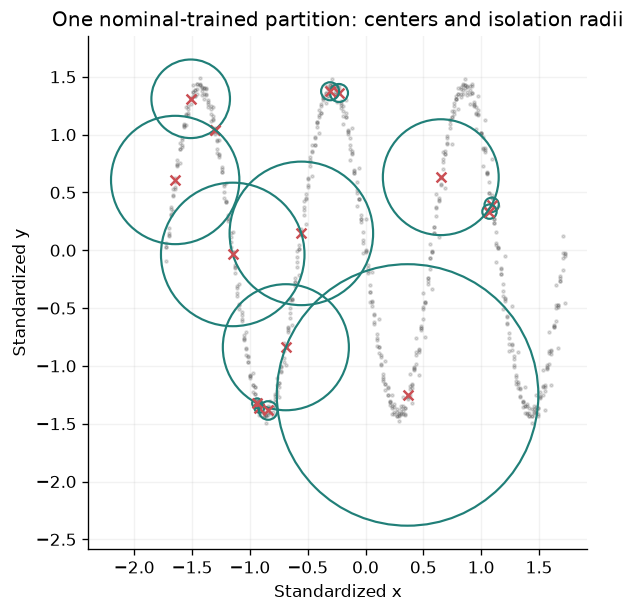

### 4. Embed and compare

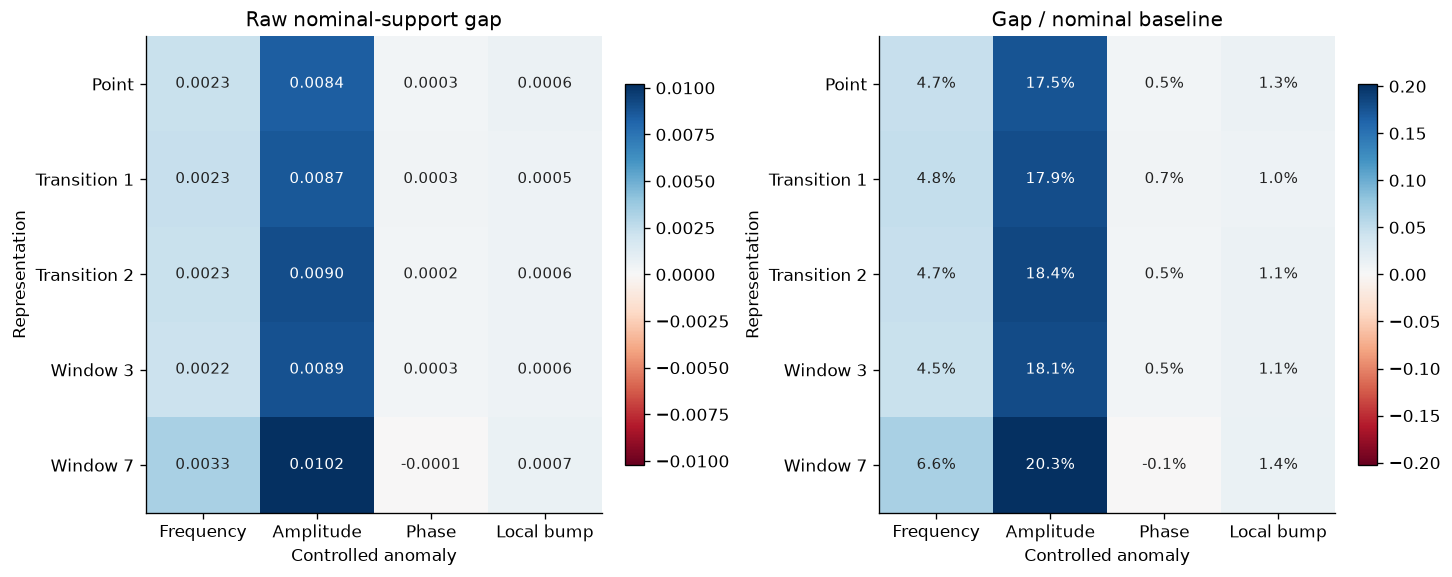

### 5. Compare recent windows

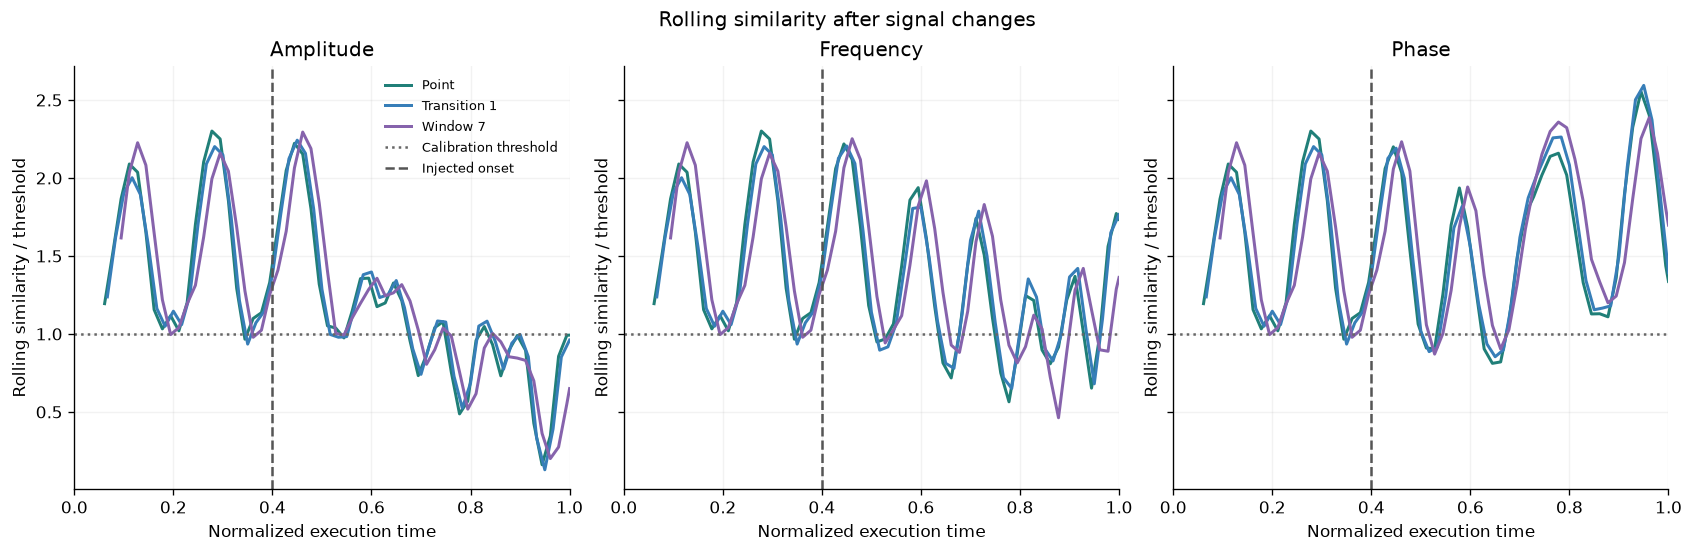

In [1]:
from IPython.display import Markdown, display

SUMMARY = {}
for step in [
    "1. Visualize oscillations",
    "2. Choose input features",
    "3. Fit isolation regions",
    "4. Embed and compare",
    "5. Compare recent windows",
]:
    display(Markdown(f"### {step}"))
    SUMMARY[step] = display(Markdown("Pending run."), display_id=True)

In [2]:
import sys
from collections.abc import Sequence
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.figure import Figure
from matplotlib.patches import Circle
from numpy.typing import NDArray
from scipy.sparse import csr_matrix

from pyidk import (
    IsolationDistributionalKernel,
    IsolationKernel,
    MinMaxScaler,
    PhaseAugmentation,
    PointRepresentation,
    SequenceBatch,
    Standardizer,
    TransitionRepresentation,
    WindowRepresentation,
    pairwise_similarity,
)
from pyidk.representation import Representation

# Support execution from either the notebook directory or repository root.
NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / "_synthetic.py").exists() else Path.cwd() / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from _synthetic import sampling_pair, sine_trajectories  # noqa: E402

SEED = 42
COLORS = {
    "Nominal": "#207f78",
    "Recovery": "#8663ac",
    "Mild failure": "#c28a18",
    "Strong failure": "#cb4f54",
    "Frequency": "#377eb8",
    "Amplitude": "#c45b79",
    "Phase": "#8663ac",
    "Local bump": "#be8027",
}
mpl.rcParams.update(
    {
        "figure.figsize": (10, 4.2),
        "figure.dpi": 120,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.16,
        "axes.axisbelow": True,
        "legend.frameon": False,
        "savefig.facecolor": "white",
    }
)
# FloatArray holds floating-point coordinates or scores; shapes are noted at each helper.
type FloatArray = NDArray[np.float64]
# The fitted representation, feature scaler, and IDK model, in that order.
type ExperiencePipeline = tuple[
    Representation, Standardizer | MinMaxScaler, IsolationDistributionalKernel
]

SUMMARY_FIGURES = set()


def show(fig: Figure, key: str | None = None) -> None:
    if key in SUMMARY:
        SUMMARY[key].update(fig)
        SUMMARY_FIGURES.add(key)
    plt.show()
    plt.close(fig)


def batch(sequences: Sequence[FloatArray]) -> SequenceBatch:
    return SequenceBatch.from_sequences(sequences)


def fit_experience(
    sequences: Sequence[FloatArray],
    representation: Representation,
    *,
    psi: int = 16,
    t: int = 96,
    seed: int = SEED,
    scaler: Standardizer | MinMaxScaler | None = None,
) -> ExperiencePipeline:
    """Fit and return the representation, scaler, and IDK model."""
    represented = representation.transform(batch(sequences))
    scaler = Standardizer() if scaler is None else scaler
    scaler.fit(represented.values)
    scaled = represented.with_values(scaler.transform(represented.values))
    model = IsolationDistributionalKernel(
        IsolationKernel(
            n_partitions=t,
            samples_per_partition=psi,
            random_state=seed,
        )
    ).fit(scaled)
    return representation, scaler, model


def represent(pipeline: ExperiencePipeline, sequences: Sequence[FloatArray]) -> SequenceBatch:
    representation, scaler, _ = pipeline
    represented = representation.transform(batch(sequences))
    return represented.with_values(scaler.transform(represented.values))


def embed(pipeline: ExperiencePipeline, sequences: Sequence[FloatArray]) -> csr_matrix:
    return pipeline[2].transform(represent(pipeline, sequences))


def squared_distance(model: IsolationDistributionalKernel, embeddings: csr_matrix) -> FloatArray:
    similarity = model.similarity(embeddings)
    return np.maximum(
        np.diag(similarity)[:, None] + np.diag(similarity)[None, :] - 2 * similarity, 0
    )


def rolling_embeddings(
    pipeline: ExperiencePipeline,
    sequences: Sequence[FloatArray],
    *,
    width: int = 12,
    stride: int = 3,
) -> tuple[csr_matrix, list[FloatArray], NDArray[np.int64]]:
    """Return window embeddings, per-sequence end times, and embedding row offsets."""
    represented = represent(pipeline, sequences)
    windows, endpoints = [], []
    for i, sequence in enumerate(sequences):
        rows = represented.sequence(i)
        offset = len(sequence) - len(rows)  # All representations here have stride 1.
        ends = np.arange(width - 1, len(rows), stride)
        if ends[-1] != len(rows) - 1:
            ends = np.r_[ends, len(rows) - 1]
        windows.extend(rows[end - width + 1 : end + 1] for end in ends)
        endpoints.append((ends + offset) / (len(sequence) - 1))
    embeddings = pipeline[2].transform(batch(windows))
    counts = [len(end) for end in endpoints]
    return embeddings, endpoints, np.r_[0, np.cumsum(counts)]


def rolling_scores(
    pipeline: ExperiencePipeline,
    sequences: Sequence[FloatArray],
    reference: csr_matrix,
    *,
    width: int = 12,
    stride: int = 3,
    k: int = 5,
) -> tuple[list[FloatArray], list[FloatArray]]:
    """Return per-sequence window end times and matching similarity scores."""
    embeddings, endpoints, offsets = rolling_embeddings(
        pipeline,
        sequences,
        width=width,
        stride=stride,
    )
    similarity = pipeline[2].similarity(embeddings, reference)
    k = min(k, similarity.shape[1])
    scores = np.partition(similarity, -k, axis=1)[:, -k:].mean(axis=1)
    return endpoints, [scores[a:b] for a, b in zip(offsets[:-1], offsets[1:], strict=True)]


def first_alarm(
    times: FloatArray,
    scores: FloatArray,
    threshold: float,
    onset: float = 0.0,
    persistence: int = 3,
) -> float:
    low = scores < threshold
    for end in range(persistence - 1, len(low)):
        start = end - persistence + 1
        if times[start] >= onset and low[start : end + 1].all():
            return float(times[end])  # Alarm time is when persistence is confirmed.
    return np.nan

## 1. Visualize oscillations

Nominal signals have small variations in amplitude, phase, frequency, and noise. Matched test signals add faster oscillation, amplitude growth, a temporary phase shift, or a local bump. Dashed lines mark when each change starts.


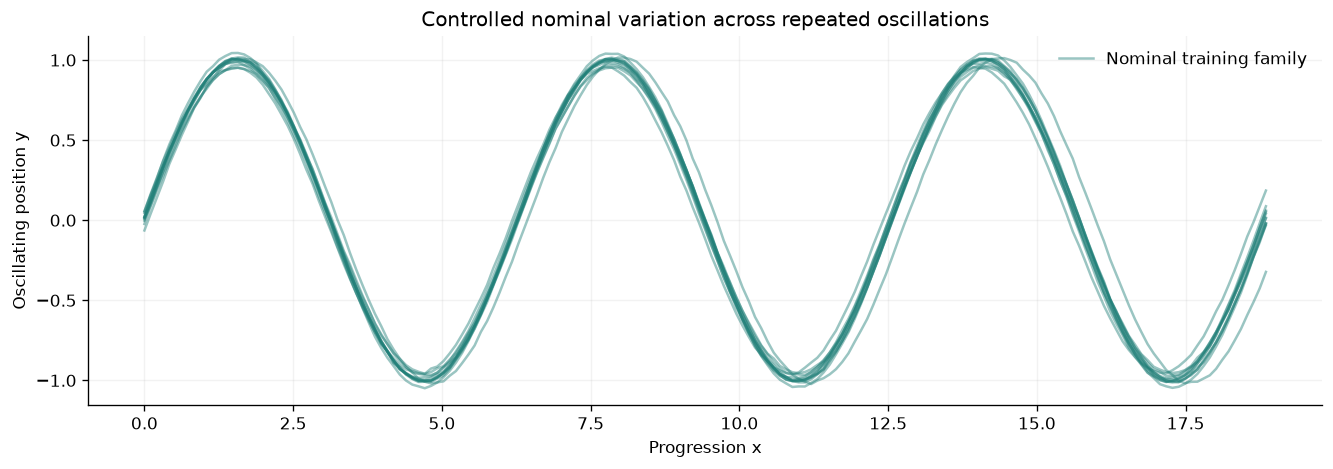

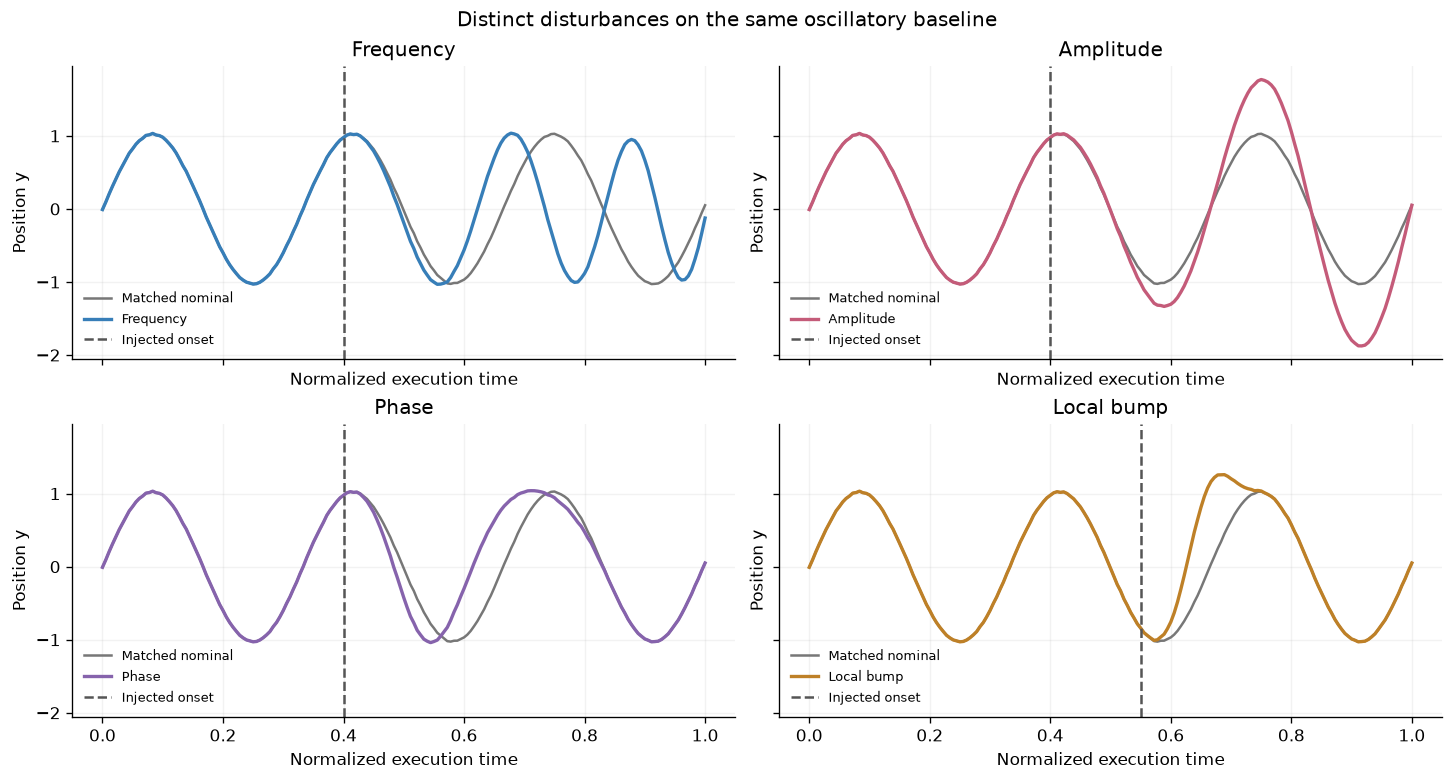

In [3]:
sine_u, sine_train, sine_cal, sine_test, sine_groups, sine_onsets = sine_trajectories(SEED + 1)
fig, ax = plt.subplots(figsize=(11, 3.8), layout="constrained")
for i, sequence in enumerate(sine_train):
    ax.plot(
        *sequence.T,
        color=COLORS["Nominal"],
        alpha=0.45,
        label="Nominal training family" if i == 0 else None,
    )
ax.set(
    xlabel="Progression x",
    ylabel="Oscillating position y",
    title="Controlled nominal variation across repeated oscillations",
)
ax.legend()
show(fig)

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True, sharey=True, layout="constrained")
for ax, (name, sequences) in zip(axes.flat, sine_groups.items(), strict=True):
    ax.plot(sine_u, sine_test[0][:, 1], color="#777777", lw=1.5, label="Matched nominal")
    ax.plot(sine_u, sequences[0][:, 1], color=COLORS[name], lw=2, label=name)
    ax.axvline(sine_onsets[name], color="#555555", ls="--", label="Injected onset")
    ax.set(title=name, xlabel="Normalized execution time", ylabel="Position y")
    ax.legend(fontsize=8, loc="lower left")
fig.suptitle("Distinct disturbances on the same oscillatory baseline")
show(fig, "1. Visualize oscillations")

## 2. Choose input features

A y value alone cannot distinguish rising from falling. A transition includes the next sample; a window includes several samples. Sequence phase adds where the sample occurs in the execution and assumes alignment.

The example below uses y alone to expose this ambiguity. The full [x, y] input also records progression through x.


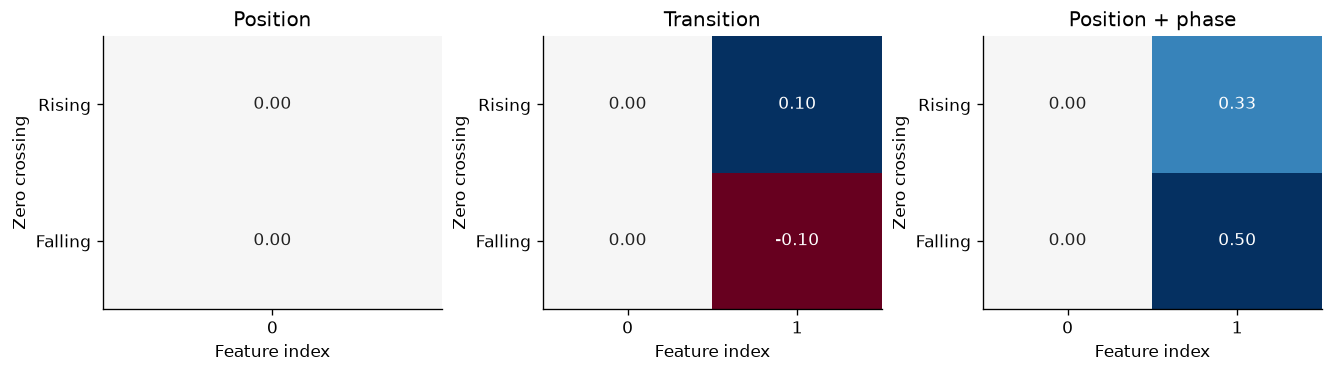

In [4]:
clean_y = np.sin(6 * np.pi * sine_u)
rising, falling = 60, 90
clean_y[[rising, falling]] = 0.0
feature_choices = {
    "Position": PointRepresentation(),
    "Transition": TransitionRepresentation(),
    "Position + phase": PhaseAugmentation(),
}
fig, axes = plt.subplots(1, 3, figsize=(11, 3), layout="constrained")
for ax, (name, representation) in zip(axes, feature_choices.items(), strict=True):
    values = representation.transform(batch([clean_y[:, None]])).values[[rising, falling]]
    limit = max(np.abs(values).max(), 0.01)
    ax.imshow(values, cmap="RdBu", vmin=-limit, vmax=limit, aspect="auto")
    for (i, j), value in np.ndenumerate(values):
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.6 * limit else "#222222",
        )
    ax.set(
        title=name,
        yticks=[0, 1],
        yticklabels=["Rising", "Falling"],
        xticks=range(values.shape[1]),
        xlabel="Feature index",
        ylabel="Zero crossing",
    )
    ax.grid(False)
show(fig, "2. Choose input features")

## 3. Fit isolation regions

For each representation, fit scaling and IK on nominal training data only. Each sampled center's radius is its nearest sampled neighbor's distance. A point activates its nearest center only if inside that radius.

The figure shows one learned partition for [x, y]. Temporal inputs use the same rule in more dimensions.


| Representation | Feature dimension | Raw sample span | Fraction of one cycle |
|:--|--:|--:|--:|
| Point | 2 | 1 | 0.000 |
| Transition 1 | 4 | 2 | 0.017 |
| Transition 2 | 4 | 3 | 0.033 |
| Window 3 | 6 | 3 | 0.033 |
| Window 7 | 14 | 7 | 0.100 |

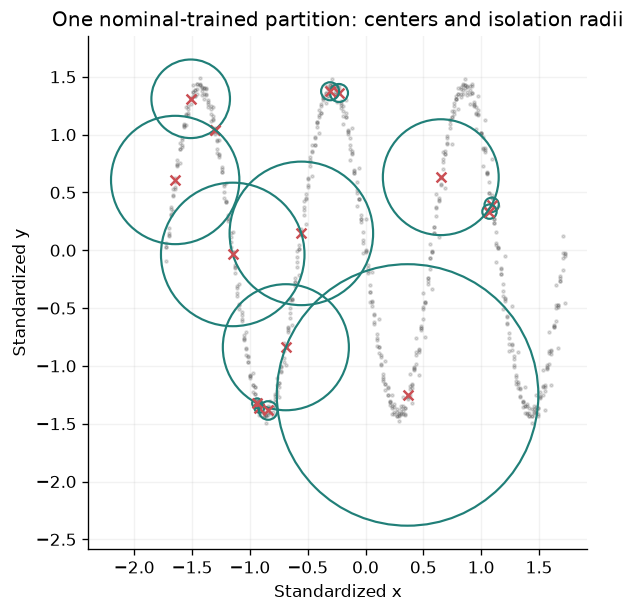

In [5]:
sine_reps = {
    "Point": PointRepresentation(),
    "Transition 1": TransitionRepresentation(lags=(0, 1)),
    "Transition 2": TransitionRepresentation(lags=(0, 2)),
    "Window 3": WindowRepresentation(length=3),
    "Window 7": WindowRepresentation(length=7),
}
sine_pipelines = {
    name: fit_experience(sine_train, representation, t=64)
    for name, representation in sine_reps.items()
}
support_steps = [1, 2, 3, 3, 7]
display(
    Markdown(
        "| Representation | Feature dimension | Raw sample span | Fraction of one cycle |\n"
        "|:--|--:|--:|--:|\n"
        + "\n".join(
            f"| {name} | {represent(pipeline, [sine_test[0]]).n_features} | {steps} | "
            f"{(steps - 1) * 3 / (len(sine_u) - 1):.3f} |"
            for (name, pipeline), steps in zip(sine_pipelines.items(), support_steps, strict=True)
        )
    )
)

point_pipeline = sine_pipelines["Point"]
training_points = represent(point_pipeline, sine_train).values
basis = point_pipeline[2].point_kernel.basis_
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.scatter(*training_points[::3].T, s=3, color="#555555", alpha=0.2)
for center, radius in zip(basis.centers[0], basis.radii[0], strict=True):
    ax.add_patch(Circle(center, radius, fill=False, edgecolor="#207f78", lw=1.3))
    ax.scatter(*center, marker="x", color="#cb4f54", s=35)
ax.set(
    xlabel="Standardized x",
    ylabel="Standardized y",
    aspect="equal",
    title="One nominal-trained partition: centers and isolation radii",
)
show(fig, "3. Fit isolation regions")

## 4. Embed and compare

IDK averages point features within each sequence. Similarity is the dot product of these averages divided by the partition count. Raw scores need not have unit self-similarity.

### 4.1. Distinguish rising from falling

At equal y values, position embeddings match. Transitions and phase can separate the two crossings. Phase identifies sequence position, not velocity.


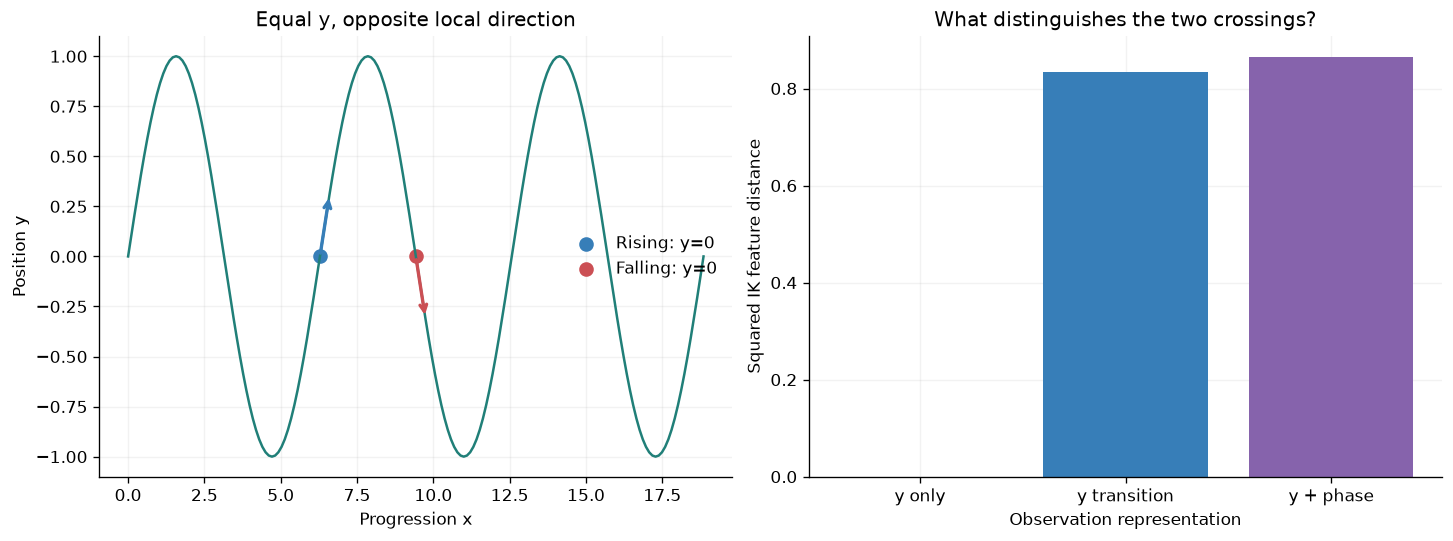

| Representation | Crossing similarity | Squared feature distance |
|:--|--:|--:|
| y only | 0.7083 | 0.0000 |
| y transition | 0.2917 | 0.8333 |
| y + phase | 0.2188 | 0.8646 |

In [6]:
clean_x = 6 * np.pi * sine_u
clean_y = np.sin(clean_x)
rising, falling = 60, 90
clean_y[[rising, falling]] = 0.0  # Exact analytic crossings, avoiding roundoff.
reduced_train = [s[:, 1:2] for s in sine_train]
reduced_clean = clean_y[:, None]
ambiguity_reps = {
    "y only": PointRepresentation(),
    "y transition": TransitionRepresentation(),
    "y + phase": PhaseAugmentation(),
}
ambiguity_values = []
for label, representation in ambiguity_reps.items():
    pipeline = fit_experience(reduced_train, representation)
    represented = represent(pipeline, [reduced_clean])
    features = pipeline[2].point_kernel.transform(represented.values[[rising, falling]])
    similarity = pairwise_similarity(features, n_partitions=96)
    distance = max(similarity[0, 0] + similarity[1, 1] - 2 * similarity[0, 1], 0)
    ambiguity_values.append((label, similarity[0, 1], distance))
assert ambiguity_values[0][2] < 1e-12

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout="constrained")
axes[0].plot(clean_x, clean_y, color="#207f78")
for i, label, color in [(rising, "Rising", "#377eb8"), (falling, "Falling", "#cb4f54")]:
    axes[0].scatter(clean_x[i], clean_y[i], c=color, s=60, label=f"{label}: y=0")
    axes[0].annotate(
        "",
        xy=(clean_x[i + 3], clean_y[i + 3]),
        xytext=(clean_x[i], clean_y[i]),
        arrowprops={"arrowstyle": "->", "color": color, "lw": 2},
    )
axes[0].set(xlabel="Progression x", ylabel="Position y", title="Equal y, opposite local direction")
axes[0].legend()
axes[1].bar(
    [v[0] for v in ambiguity_values],
    [v[2] for v in ambiguity_values],
    color=["#207f78", "#377eb8", "#8663ac"],
)
axes[1].set(
    xlabel="Observation representation",
    ylabel="Squared IK feature distance",
    title="What distinguishes the two crossings?",
)
show(fig, "Oscillatory ambiguity")
display(
    Markdown(
        "| Representation | Crossing similarity | Squared feature distance |\n|:--|--:|--:|\n"
        + "\n".join(
            f"| {label} | {sim:.4f} | {dist:.4f} |" for label, sim, dist in ambiguity_values
        )
    )
)

### 4.2. Change sampling density

Uniform and slow-down samples follow the same curve. Extra dwell time changes the average features. Duplicating every sample equally does not.

Keep the basis fixed for this comparison. Kernel distance includes both self-similarities; a changed distribution need not have lower raw cross-similarity.


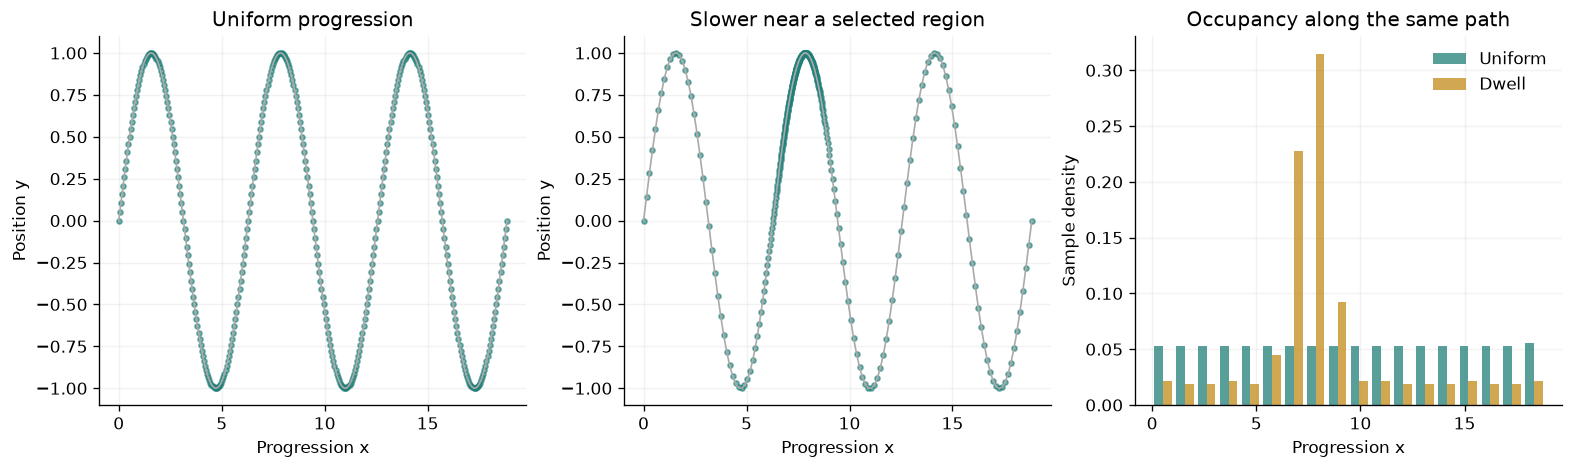

| Comparison to uniform | Raw IDK similarity | Squared embedding distance |
|:--|--:|--:|
| Identical sampling | 0.04845 | 0.00000 |
| Selective dwell | 0.04993 | 0.10441 |
| Every observation duplicated | 0.04845 | 0.00000 |

In [7]:
uniform_path, dwell_path = sampling_pair()
density_pipeline = fit_experience(sine_train, PointRepresentation(), scaler=MinMaxScaler())
density_model = density_pipeline[2]
density_sequences = [
    uniform_path,
    uniform_path.copy(),
    dwell_path,
    np.repeat(uniform_path, 2, axis=0),
]
density_features = embed(density_pipeline, density_sequences)
density_similarity = density_model.similarity(density_features)
density_distances = squared_distance(density_model, density_features)
assert np.max(np.abs((density_features[0] - density_features[3]).toarray())) < 1e-12

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout="constrained")
for ax, sequence, title in zip(
    axes[:2],
    [uniform_path, dwell_path],
    ["Uniform progression", "Slower near a selected region"],
    strict=True,
):
    ax.plot(*uniform_path.T, color="#aaaaaa", lw=1)
    ax.scatter(*sequence.T, s=9, color="#207f78", alpha=0.6)
    ax.set(title=title, xlabel="Progression x", ylabel="Position y")
axes[2].hist(
    [uniform_path[:, 0], dwell_path[:, 0]],
    bins=18,
    density=True,
    label=["Uniform", "Dwell"],
    color=["#207f78", "#c28a18"],
    alpha=0.75,
)
axes[2].set(title="Occupancy along the same path", xlabel="Progression x", ylabel="Sample density")
axes[2].legend()
show(fig)
display(
    Markdown(
        "| Comparison to uniform | Raw IDK similarity | Squared embedding distance |\n"
        "|:--|--:|--:|\n"
        + "\n".join(
            f"| {label} | {density_similarity[0, i]:.5f} | {density_distances[0, i]:.5f} |"
            for i, label in [
                (1, "Identical sampling"),
                (2, "Selective dwell"),
                (3, "Every observation duplicated"),
            ]
        )
    )
)

### 4.3. Change the training data

Now hold the query points and scaling fixed, but fit on uniform versus dwell-weighted samples. Any similarity change comes from the fitted basis.


In [8]:
fixed_scaler = density_pipeline[1]
fixed_queries = fixed_scaler.transform(uniform_path[[138, 145]])
basis_scores = []
for label, reference_path in [("Uniform reference", uniform_path), ("Dwell reference", dwell_path)]:
    point_kernel = IsolationKernel(
        n_partitions=250,
        samples_per_partition=16,
        random_state=SEED,
    ).fit(fixed_scaler.transform(reference_path))
    query_features = point_kernel.transform(fixed_queries)
    score = pairwise_similarity(query_features, n_partitions=250)[0, 1]
    basis_scores.append((label, score))
display(
    Markdown(
        "Fixed scaled query distance: "
        f"**{np.linalg.norm(fixed_queries[0] - fixed_queries[1]):.4f}**.\n\n"
        "| Basis training data | Same query-pair IK similarity |\n|:--|--:|\n"
        + "\n".join(f"| {label} | {score:.4f} |" for label, score in basis_scores)
        + f"\n\nWith the original fixed basis, selective dwell has squared distance "
        f"**{density_distances[0, 2]:.5f}**, while its raw cross-similarity changes by "
        f"**{density_similarity[0, 2] - density_similarity[0, 1]:+.5f}** "
        "from the identity control. "
        "Different occupancy does not imply a lower raw cross-similarity."
    )
)

Fixed scaled query distance: **0.0774**.

| Basis training data | Same query-pair IK similarity |
|:--|--:|
| Uniform reference | 0.4160 |
| Dwell reference | 0.0040 |

With the original fixed basis, selective dwell has squared distance **0.10441**, while its raw cross-similarity changes by **+0.00147** from the identity control. Different occupancy does not imply a lower raw cross-similarity.

### 4.4. Compare signal changes across representations

Subtract mean anomaly-to-reference similarity from mean nominal-to-reference similarity. A positive gap means the anomaly has lower nominal similarity. Divide by the nominal baseline to compare relative gaps; this is not classification accuracy.


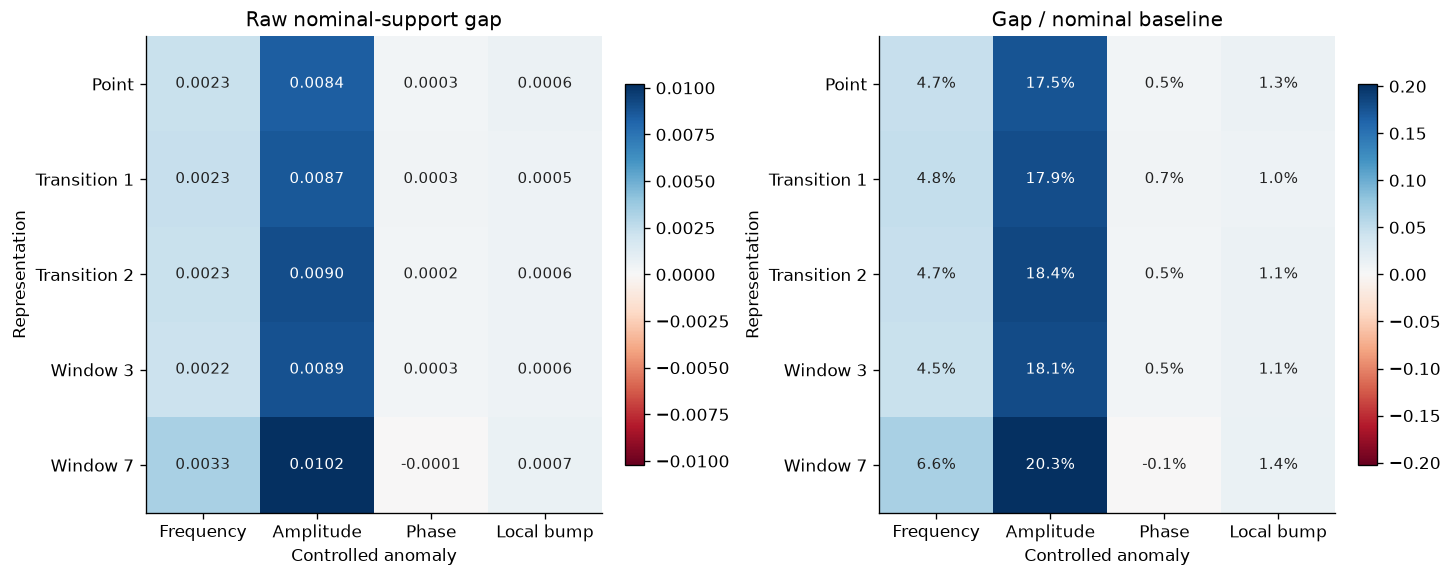

| Representation | Nominal-to-nominal mean | Nominal-to-frequency mean | Nominal-to-amplitude mean | Nominal-to-phase mean | Nominal-to-local bump mean |
|:--|--:|--:|--:|--:|--:|
| Point | 0.04812 | 0.04584 | 0.03971 | 0.04786 | 0.04752 |
| Transition 1 | 0.04847 | 0.04612 | 0.03978 | 0.04813 | 0.04796 |
| Transition 2 | 0.04920 | 0.04691 | 0.04016 | 0.04896 | 0.04865 |
| Window 3 | 0.04926 | 0.04702 | 0.04033 | 0.04900 | 0.04870 |
| Window 7 | 0.05044 | 0.04712 | 0.04022 | 0.05051 | 0.04973 |

The largest relative gap in this run is **20.3%**, for **Window 7 / Amplitude**. This is a descriptive maximum, not a tuned model selection result.

In [9]:
anomaly_names = list(sine_groups)
gaps = np.empty((len(sine_pipelines), len(anomaly_names)))
baselines = np.empty(len(sine_pipelines))
anomaly_means = np.empty_like(gaps)
for i, pipeline in enumerate(sine_pipelines.values()):
    model = pipeline[2]
    reference = embed(pipeline, sine_cal)
    baselines[i] = model.similarity(embed(pipeline, sine_test), reference).mean()
    for j, name in enumerate(anomaly_names):
        anomaly_means[i, j] = model.similarity(embed(pipeline, sine_groups[name]), reference).mean()
        gaps[i, j] = baselines[i] - anomaly_means[i, j]
relative_gaps = gaps / baselines[:, None]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), layout="constrained")
for ax, values, title, fmt in zip(
    axes,
    [gaps, relative_gaps],
    ["Raw nominal-support gap", "Gap / nominal baseline"],
    [".4f", ".1%"],
    strict=True,
):
    limit = max(np.abs(values).max(), 1e-8)
    im = ax.imshow(values, cmap="RdBu", vmin=-limit, vmax=limit, aspect="auto")
    ax.set(
        xticks=range(len(anomaly_names)),
        xticklabels=anomaly_names,
        yticks=range(len(sine_pipelines)),
        yticklabels=list(sine_pipelines),
        xlabel="Controlled anomaly",
        ylabel="Representation",
        title=title,
    )
    for (i, j), value in np.ndenumerate(values):
        ax.text(
            j,
            i,
            format(value, fmt),
            ha="center",
            va="center",
            color="white" if abs(value) > 0.6 * limit else "#222222",
            fontsize=9,
        )
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8)
show(fig, "4. Embed and compare")
display(
    Markdown(
        "| Representation | Nominal-to-nominal mean | "
        + " | ".join(f"Nominal-to-{name.lower()} mean" for name in anomaly_names)
        + " |\n|:--|"
        + "--:|" * (len(anomaly_names) + 1)
        + "\n"
        + "\n".join(
            f"| {name} | {baselines[i]:.5f} | "
            + " | ".join(f"{value:.5f}" for value in anomaly_means[i])
            + " |"
            for i, name in enumerate(sine_pipelines)
        )
    )
)
largest = np.unravel_index(np.argmax(relative_gaps), relative_gaps.shape)
display(
    Markdown(
        f"The largest relative gap in this run is **{relative_gaps[largest]:.1%}**, "
        f"for **{list(sine_pipelines)[largest[0]]} / {anomaly_names[largest[1]]}**. "
        "This is a descriptive maximum, not a tuned model selection result."
    )
)

## 5. Compare recent windows

For each representation, compare recent windows to nominal training windows. Thresholds come from separate calibration signals; alarms require consecutive low scores.

Longer feature windows consume more raw samples. Scores use the last consumed sample's time, so no future samples are used. Compare delays, missed detections, and nominal false alarms together.


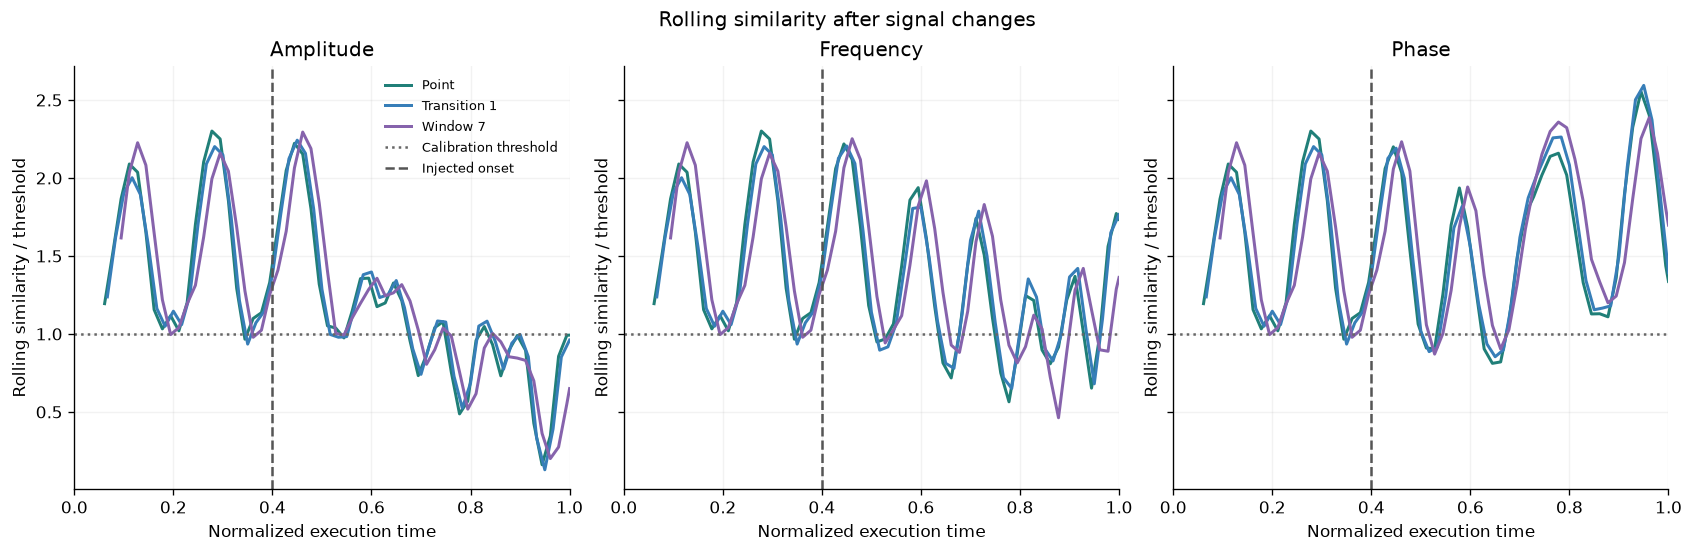

| Representation | Anomaly | Post-onset detected | Median latency (detected only) | Pre-onset alarm fraction |
|:--|:--|--:|--:|--:|
| Point | Amplitude | 8/8 | 0.311 | 0.0% |
| Point | Frequency | 8/8 | 0.394 | 0.0% |
| Point | Phase | 8/8 | 0.261 | 0.0% |
| Transition 1 | Amplitude | 8/8 | 0.317 | 0.0% |
| Transition 1 | Frequency | 2/8 | 0.483 | 0.0% |
| Transition 1 | Phase | 8/8 | 0.267 | 0.0% |
| Window 7 | Amplitude | 8/8 | 0.411 | 0.0% |
| Window 7 | Frequency | 8/8 | 0.411 | 0.0% |
| Window 7 | Phase | 0/8 | not detected | 0.0% |

| Representation | Held-out nominal execution alarm fraction |
|:--|--:|
| Point | 0.0% |
| Transition 1 | 0.0% |
| Window 7 | 0.0% |

Latency runs from injection to confirmation of three low scores in normalized execution time. Post-onset detections include executions with pre-onset alarms, which are disclosed separately. Small synthetic samples and overlapping windows do not establish calibrated error rates.

In [10]:
rolling_rep_names = ["Point", "Transition 1", "Window 7"]
rolling_anomalies = ["Amplitude", "Frequency", "Phase"]
rolling_colors = ["#207f78", "#377eb8", "#8663ac"]
sine_rolling = {}
latency_rows = []
nominal_alarm_rows = []
latency_results = {}
for rep_name in rolling_rep_names:
    pipeline = sine_pipelines[rep_name]
    reference, _, _ = rolling_embeddings(pipeline, sine_train, stride=6)
    _, calibration_scores = rolling_scores(pipeline, sine_cal, reference)
    threshold = float(np.quantile(np.concatenate(calibration_scores), 0.05))
    assert threshold > 0
    nominal_times, nominal_scores = rolling_scores(pipeline, sine_test, reference)
    nominal_alarms = [
        np.isfinite(first_alarm(t, s, threshold))
        for t, s in zip(nominal_times, nominal_scores, strict=True)
    ]
    nominal_alarm_rows.append(f"| {rep_name} | {np.mean(nominal_alarms):.1%} |")
    for name in rolling_anomalies:
        times, scores = rolling_scores(pipeline, sine_groups[name], reference)
        onset = sine_onsets[name]
        alarms = np.array(
            [first_alarm(t, s, threshold, onset) for t, s in zip(times, scores, strict=True)]
        )
        pre_alarms = [
            np.isfinite(first_alarm(t[t < onset], s[t < onset], threshold))
            for t, s in zip(times, scores, strict=True)
        ]
        detected = np.isfinite(alarms)
        median = np.median(alarms[detected] - onset) if detected.any() else np.nan
        latency_results[rep_name, name] = median
        latency_rows.append(
            f"| {rep_name} | {name} | {detected.sum()}/{len(alarms)} | "
            f"{'not detected' if np.isnan(median) else f'{median:.3f}'} | "
            f"{np.mean(pre_alarms):.1%} |"
        )
        sine_rolling[rep_name, name] = times[0], scores[0] / threshold

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, layout="constrained")
for ax, name in zip(axes, rolling_anomalies, strict=True):
    for rep_name, color in zip(rolling_rep_names, rolling_colors, strict=True):
        times, scores = sine_rolling[rep_name, name]
        ax.plot(times, scores, color=color, lw=1.8, label=rep_name)
    ax.axhline(1, color="#666666", ls=":", label="Calibration threshold")
    ax.axvline(sine_onsets[name], color="#555555", ls="--", label="Injected onset")
    ax.set(
        title=name,
        xlabel="Normalized execution time",
        ylabel="Rolling similarity / threshold",
        xlim=(0, 1),
    )
axes[0].legend(fontsize=8)
fig.suptitle("Rolling similarity after signal changes")
show(fig, "5. Compare recent windows")
display(
    Markdown(
        "| Representation | Anomaly | Post-onset detected | Median latency (detected only) | "
        "Pre-onset alarm fraction |\n|:--|:--|--:|--:|--:|\n"
        + "\n".join(latency_rows)
        + "\n\n| Representation | Held-out nominal execution alarm fraction |\n|:--|--:|\n"
        + "\n".join(nominal_alarm_rows)
        + "\n\nLatency runs from injection to confirmation of three low scores in normalized "
        "execution time. Post-onset detections include executions with pre-onset alarms, which "
        "are disclosed separately. Small synthetic samples and overlapping windows do not "
        "establish calibrated error rates."
    )
)

assert len(SUMMARY_FIGURES) == len(SUMMARY)
assert ambiguity_values[0][2] < 1e-12
assert np.isfinite(gaps).all()
for name, sequences in sine_groups.items():
    before = sine_u <= sine_onsets[name]
    assert np.allclose(sequences[0][before], sine_test[0][before])